Using neuroCombat, harmonizing variables that we want to "clean out" of the data 

In [ ]:
import pandas as pd
import neuroCombat
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')
print(df.columns)

Index(['subject_id', 'session_id', 'region_label', 'tissue_type', 'volume_mm3',
       'tiv', 'sex', 'institute', 'manufacturer', 'age_in_years', 'dob',
       'gm_volume_cm3', 'protocol', 'birth_year', 'Unnamed: 0', 'atlas_name',
       'scan_time', 'age_at_scan', 'weight', 'directory_path',
       'estimated_critical_info', 'scan_date', 'file_path',
       'classification_label'],
      dtype='object')


In [19]:
tested_batch = 'manufacturer'  # Column indicating the batch variable

1. Data Matrix (df_features) - rows are imaging features (454 brain regions) and columns are individual scans (subjects).
2. Covariate Table (df_covariates)- row is a subject and columns include:
    a. Batch ID: The unique identifier for the scanner/site.
    b. Biological Covariates: Variables you want to protect (Age, Sex, Diagnosis).

In [20]:
# df_features has regions as columns (454) and subjects as rows (1000+), and the data is volume measurements
df_features = df.pivot_table(
    index='subject_id', 
    columns='region_label', 
    values='volume_mm3', 
    aggfunc='mean' # or 'sum', etc.
)

# index is subject_id, order them 
df_features = df_features.sort_index()

df_covariates = df.drop_duplicates(subset=['subject_id'])[
    ['subject_id', 'sex', 'institute', 'manufacturer', 'age_in_years',  'birth_year']] # add protocol and tiv, but notice they're missing for some subjects

# index is subject_id, order them 
df_covariates = df_covariates.set_index('subject_id').sort_index()

# validate alignment
print("Covariates Index (first 5):", df_covariates.index[:5].tolist())
print("Before Features Index (first 5):", df_features.index[:5].tolist())

Covariates Index (first 5): ['0873', 'BB00005', 'BB01209', 'BBK0001', 'BBK0002']
Before Features Index (first 5): ['0873', 'BB00005', 'BB01209', 'BBK0001', 'BBK0002']


# Before Harmonization


1. check collinearity between the batch and the features, to make sure I don't harmonize features (brain volume)
 If they overlap (earlier birth years correlation with institute = 1 I have collinearity and harmonizing can harm the biological effect)
 Do so by presenting the distribution of batches (manufactoror, institute etc. and birth year).

2. make sure the subgroups in the batch are big enough to be meaningfull

In [21]:
# how many scans are per group in a batch: (at least 20 per group)
for col in ['institute', 'manufacturer']:
    print(f"Counts for {col}:")
    print(df_covariates[col].value_counts())
    print("\n")

Counts for institute:
institute
Tel-Aviv University       3080
ICHILOV TEL AVIV           511
SHEBA_ MEDICAL_ CENTER     166
Name: count, dtype: int64


Counts for manufacturer:
manufacturer
SIEMENS               3080
GE MEDICAL SYSTEMS     677
Name: count, dtype: int64




3. look for missing values and remove them (as neuroCombat can't handle missing values)

In [23]:
# are there any missing values?
print("Missing values in df_features:", df_features.isnull().sum().sum())

# separate the entries with missing values
missing_values_features = df_features[df_features.isnull().any(axis=1)]
print("Missing values in df_covariates:", df_covariates.isnull().sum())

Missing values in df_features: 231
Missing values in df_covariates: sex             0
institute       0
manufacturer    0
age_in_years    0
birth_year      0
dtype: int64


In [24]:
# remove entries with missing values from both dataframes
df_features = df_features.dropna()
df_covariates = df_covariates.loc[df_features.index]

# Running harmonization

In [25]:
from neuroCombat import neuroCombat
# 2. Transpose features: NeuroCombat needs (features x subjects)
# We drop the 'SubjectID' column so only numerical brain data remains
data = df_features.transpose().to_numpy()

# 3. Define the batch (scanner/site)
batch = df_covariates[tested_batch].tolist()

# 4. Define biological covariates to PRESERVE
# 'categorical_cols' tells the model these are not continuous numbers
categorical_cols = ['sex']
continuous_cols = ['age_in_years', 'birth_year']

# 5. Run NeuroCombat
# eb=True uses Empirical Bayes to pool information across features
result = neuroCombat(dat=data,
                     covars=df_covariates,
                     batch_col=tested_batch,
                     categorical_cols=categorical_cols,
                     continuous_cols=continuous_cols)

# 6. Extract the harmonized data
# The output is a dictionary; 'data' contains the corrected matrix
harmonized_data_matrix = result['data']
# convert back to DataFrame to keep track of indices and columns
harmonized_data_matrix = pd.DataFrame(harmonized_data_matrix,
                                      index=df_features.columns,
                                      columns=df_features.index)

# 7. Convert back to a DataFrame for analysis
df_harmonized = pd.DataFrame(harmonized_data_matrix.transpose(), 
                             columns=df_features.columns)

# sort indices to match original data
df_harmonized = df_harmonized.sort_index()

[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data


# Visualization

/tmp/ipykernel_226460/734113646.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_before, x=tested_batch, y=target_region, ax=axes[0], palette="Set2")
/tmp/ipykernel_226460/734113646.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_after, x=tested_batch, y=target_region, ax=axes[1], palette="Set2")


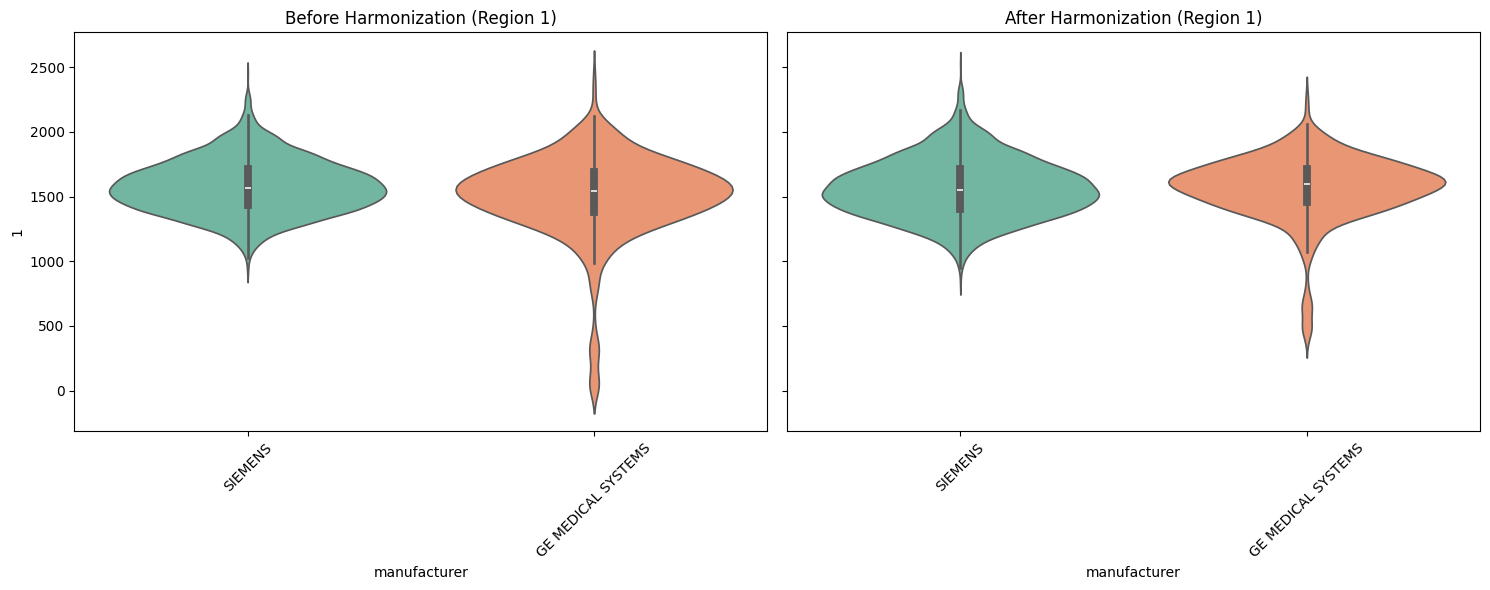

In [ ]:
# pick a region to visualize (e.g., column 1)
target_region = 1 

# 1. Prepare data for plotting
# We use the index-aligned dataframes we created before NeuroCombat
plot_before = pd.concat([df_covariates[tested_batch], df_features[target_region]], axis=1)
plot_after = pd.concat([df_covariates[tested_batch], df_harmonized[target_region]], axis=1)

# 2. Create Side-by-Side Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Plot Before
sns.violinplot(data=plot_before, x=tested_batch, y=target_region, ax=axes[0], palette="Set2")
axes[0].set_title(f"Before Harmonization (Region {target_region})")
axes[0].tick_params(axis='x', rotation=45)

# Plot After
sns.violinplot(data=plot_after, x=tested_batch, y=target_region, ax=axes[1], palette="Set2")
axes[1].set_title(f"After Harmonization (Region {target_region})")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()